# Sistema de Recomendação de Filmes com Machine Learning

## Contexto

---

Você foi contratado como cientista de dados por uma plataforma de streaming que deseja melhorar significativamente a experiência dos usuários através de recomendações personalizadas de filmes. A empresa observou que sistemas de recomendação tradicionais frequentemente dependem de sinais de engajamento como curtidas, compartilhamentos e tempo de visualização, mas deseja ir além, criando um sistema que realmente entenda as preferências individuais de cada usuário. Sua missão é utilizar técnicas de **Machine Learning**, especificamente **Filtragem Colaborativa**, para construir um modelo que preveja avaliações de filmes e gere recomendações personalizadas que aumentem o engajamento e a satisfação dos usuários.

## Objetivos de Aprendizagem

---

Ao final deste exercício, você será capaz de:

- Compreender os fundamentos de sistemas de recomendação e filtragem colaborativa
- Explorar e preparar dados de avaliações de usuários para machine learning
- Implementar algoritmos de recomendação como K-Nearest Neighbors (KNN) e SVD
- Calcular métricas de similaridade entre usuários e itens
- Avaliar a performance de modelos de recomendação
- Gerar recomendações personalizadas para usuários específicos
- Comparar diferentes abordagens de filtragem colaborativa

## Competências a Serem Desenvolvidas

---

- Exploração e análise de dados de interação usuário-item (matriz de utilidade)
- Pré-processamento de dados esparsos (sparse data) para sistemas de recomendação
- Implementação de filtragem colaborativa baseada em usuário e baseada em item
- Cálculo de similaridade usando cosine similarity e correlação de Pearson
- Treinamento e validação de modelos de Machine Learning (KNN, SVD)
- Decomposição matricial e extração de features latentes
- Validação cruzada e métricas de avaliação (RMSE, MAE, Precision@K)
- Tratamento de problemas comuns: cold start, data sparsity, popularity bias

## Dependências e Configurações

---

In [1]:
# Bibliotecas fundamentais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# Para sistemas de recomendação (opcional)
# pip install scikit-surprise
# from surprise import Dataset, Reader, KNNBasic, SVD
# from surprise.model_selection import cross_validate, train_test_split as surprise_split
# from surprise import accuracy

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Para reprodutibilidade
np.random.seed(42)

## Conjunto de Dados

---

Crie um DataFrame simulando avaliações de filmes por usuários (inspirado no dataset MovieLens):

```python
{
    'user_id': [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 
                1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'movie_id': [101, 102, 103, 101, 102, 104, 101, 103, 105, 102, 104, 105, 103, 104, 105,
                 104, 103, 102, 101, 102, 105, 105, 104, 103, 101, 106, 106, 106, 106, 106],
    'rating': [5.0, 4.0, 3.5, 4.5, 5.0, 3.0, 5.0, 4.5, 2.0, 4.0, 3.5, 2.5, 3.0, 3.0, 2.0,
               4.5, 4.0, 5.0, 4.5, 3.5, 3.0, 2.5, 4.0, 3.5, 4.0, 2.5, 3.0, 3.5, 4.0, 4.5],
    'timestamp': ['2024-01-15', '2024-01-16', '2024-01-20', '2024-01-15', '2024-01-17', 
                  '2024-01-22', '2024-01-16', '2024-01-21', '2024-01-25', '2024-01-18', 
                  '2024-01-23', '2024-01-26', '2024-01-19', '2024-01-24', '2024-01-27',
                  '2024-02-01', '2024-02-02', '2024-02-03', '2024-02-04', '2024-02-05',
                  '2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-10',
                  '2024-02-11', '2024-02-12', '2024-02-13', '2024-02-14', '2024-02-15']
}
```

**Informações dos Filmes** (para contexto):

```python
movies_info = {
    'movie_id': [101, 102, 103, 104, 105, 106],
    'title': ['Matrix', 'Inception', 'Interstellar', 'The Dark Knight', 'Pulp Fiction', 'The Shawshank Redemption'],
    'genre': ['Sci-Fi|Action', 'Sci-Fi|Thriller', 'Sci-Fi|Drama', 'Action|Crime', 'Crime|Drama', 'Drama'],
    'year': [1999, 2010, 2014, 2008, 1994, 1994]
}
```

**Descrição das Colunas:**

- `user_id`: Identificador único do usuário
- `movie_id`: Identificador único do filme
- `rating`: Avaliação do usuário para o filme (escala 0-5)
- `timestamp`: Data da avaliação
- `title`: Título do filme
- `genre`: Gênero(s) do filme
- `year`: Ano de lançamento

In [2]:
ratings = {
    'user_id': [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 
                1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'movie_id': [101, 102, 103, 101, 102, 104, 101, 103, 105, 102, 104, 105, 103, 104, 105,
                 104, 103, 102, 101, 102, 105, 105, 104, 103, 101, 106, 106, 106, 106, 106],
    'rating': [5.0, 4.0, 3.5, 4.5, 5.0, 3.0, 5.0, 4.5, 2.0, 4.0, 3.5, 2.5, 3.0, 3.0, 2.0,
               4.5, 4.0, 5.0, 4.5, 3.5, 3.0, 2.5, 4.0, 3.5, 4.0, 2.5, 3.0, 3.5, 4.0, 4.5],
    'timestamp': ['2024-01-15', '2024-01-16', '2024-01-20', '2024-01-15', '2024-01-17', 
                  '2024-01-22', '2024-01-16', '2024-01-21', '2024-01-25', '2024-01-18', 
                  '2024-01-23', '2024-01-26', '2024-01-19', '2024-01-24', '2024-01-27',
                  '2024-02-01', '2024-02-02', '2024-02-03', '2024-02-04', '2024-02-05',
                  '2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-10',
                  '2024-02-11', '2024-02-12', '2024-02-13', '2024-02-14', '2024-02-15']
}

movies_info = {
    'movie_id': [101, 102, 103, 104, 105, 106],
    'title': ['Matrix', 'Inception', 'Interstellar', 'The Dark Knight', 'Pulp Fiction', 'The Shawshank Redemption'],
    'genre': ['Sci-Fi|Action', 'Sci-Fi|Thriller', 'Sci-Fi|Drama', 'Action|Crime', 'Crime|Drama', 'Drama'],
    'year': [1999, 2010, 2014, 2008, 1994, 1994]
}

## Tarefas

---

### 1. Exploração e Preparação dos Dados

---

- Carregar os dados de avaliações e informações de filmes em DataFrames separados _Dica: Use pd.DataFrame() para criar os dataframes a partir dos dicionários fornecidos._
    
- Exibir as primeiras linhas e informações básicas dos datasets _Dica: Utilize head(), info() e describe() para explorar os dados._
    
- Verificar valores ausentes e duplicados _Dica: Use isnull().sum() e duplicated().sum()._
    
- Calcular estatísticas básicas:
    
    - Número total de usuários únicos
    - Número total de filmes únicos
    - Número total de avaliações
    - Média geral de avaliações
    - Distribuição de avaliações (quantas avaliações de 1, 2, 3, 4, 5 estrelas) _Dica: Use nunique(), len(), mean() e value_counts()._
- **Visualização**: Criar um histograma da distribuição de avaliações _Dica: Use plt.hist() ou df['rating'].plot(kind='hist') para visualizar a distribuição._
    
- **Visualização**: Criar um gráfico de barras mostrando o número de avaliações por filme _Dica: Agrupe por movie_id e conte as avaliações, depois faça merge com movies_info para mostrar os títulos._
    

In [3]:
# carregar dados
notas_raw = pd.DataFrame(ratings)
filmes_raw = pd.DataFrame(movies_info)

**DATASET  AVALIAÇÕES**

In [11]:
# exibir primeiras linhas e informações básicas
notas_raw.head()

,user_id,movie_id,rating,timestamp
0,1,101,5.00,2024-01-15
1,1,102,4.00,2024-01-16
2,1,103,3.50,2024-01-20
3,2,101,4.50,2024-01-15
4,2,102,5.00,2024-01-17


In [12]:
# info
notas_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    30 non-null     int64  
 1   movie_id   30 non-null     int64  
 2   rating     30 non-null     float64
 3   timestamp  30 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 1.1+ KB


In [13]:
# describe
notas_raw.describe()

,user_id,movie_id,rating
count,30.00,30.00,30.00
mean,3.00,103.50,3.68
std,1.44,1.74,0.90
min,1.00,101.00,2.00
25%,2.00,102.00,3.00
50%,3.00,103.50,3.75
75%,4.00,105.00,4.50
max,5.00,106.00,5.00


In [18]:
# ausentes
notas_raw.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

In [20]:
# duplicatas
notas_raw.duplicated().sum()

np.int64(0)

**DATASET FILMES**

In [15]:
# primeiras linhas
filmes_raw.head()

,movie_id,title,genre,year
0,101,Matrix,Sci-Fi|Action,1999
1,102,Inception,Sci-Fi|Thriller,2010
2,103,Interstellar,Sci-Fi|Drama,2014
3,104,The Dark Knight,Action|Crime,2008
4,105,Pulp Fiction,Crime|Drama,1994


In [16]:
# informações gerais do dataset
filmes_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  6 non-null      int64 
 1   title     6 non-null      object
 2   genre     6 non-null      object
 3   year      6 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 324.0+ bytes


In [17]:
# sumario estatistico
filmes_raw.describe()

,movie_id,year
count,6.00,6.00
mean,103.50,2003.17
std,1.87,8.64
min,101.00,1994.00
25%,102.25,1995.25
50%,103.50,2003.50
75%,104.75,2009.50
max,106.00,2014.00


In [19]:
# ausentes
filmes_raw.isnull().sum()

movie_id    0
title       0
genre       0
year        0
dtype: int64

In [21]:
# duplicatas
filmes_raw.duplicated().sum()

np.int64(0)

**ESTATÍSTICAS BÁSICAS**

* Número total de usuários únicos
* Número total de filmes únicos
* Número total de avaliações
* Média geral de avaliações
* Distribuição de avaliações (quantas avaliações de 1, 2, 3, 4, 5 estrelas) Dica: Use nunique(), len(), mean() e value_counts().
* Visualização: Criar um histograma da distribuição de avaliações Dica: Use plt.hist() ou df['rating'].plot(kind='hist') para visualizar a distribuição.
* Visualização: Criar um gráfico de barras mostrando o número de avaliações por filme Dica: Agrupe por movie_id e conte as avaliações, depois faça merge com movies_info para mostrar os títulos.


In [53]:
# total de usuarios unicos
print(f'Total de usuários: { notas_raw.user_id.nunique() }')

Total de usuários: 5


In [55]:
# total de filmes únicos
print( f'Total de filmes: {filmes_raw.movie_id.nunique()}')

Total de filmes: 6


In [34]:
# total de avaliacoes
print(f'Total de avaliações: {notas_raw.shape[0]}')

Total de avaliações: 30


In [38]:
# media geral de avaliacoes
print(f'Média Geral de Avaliações: {notas_raw.rating.mean():.2f}')

Média Geral de Avaliações: 3.68


In [56]:
# tabela frequencia de avaliacoes
notas_raw.rating.value_counts().reset_index(name='qtd_avaliacoes')

,rating,qtd_avaliacoes
0,4.00,6
1,3.50,5
2,4.50,5
3,3.00,5
4,5.00,4
5,2.50,3
6,2.00,2


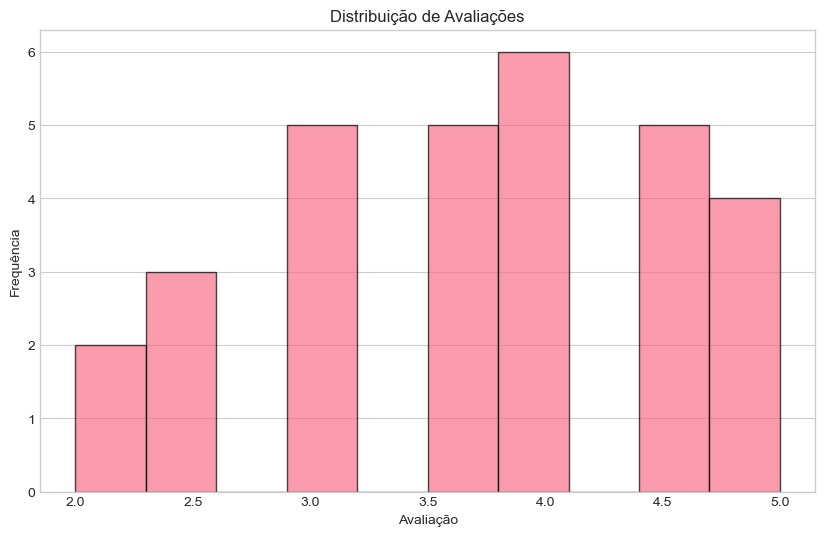

In [78]:
# histograma avaliacoes
plt.figure(figsize=(10,6))
plt.hist(
    notas_raw['rating'],
    edgecolor='black',
    alpha=.7
)
plt.xlabel('Avaliação')
plt.ylabel('Frequência')
plt.title('Distribuição de Avaliações')
plt.grid(axis='x', alpha=.0)
plt.show()

In [51]:
# plotbar o número de avaliações por filme
contagem_avaliacoes_por_filme = notas_raw.groupby('movie_id')['rating'].count().reset_index(name='num_ratings')
contagem_avaliacoes_por_filme

,movie_id,num_ratings
0,101,5
1,102,5
2,103,5
3,104,5
4,105,5
5,106,5


In [59]:
avaliacoes_por_filme = contagem_avaliacoes_por_filme.merge(filmes_raw[['movie_id', 'title']], on='movie_id')
avaliacoes_por_filme

,movie_id,num_ratings,title
0,101,5,Matrix
1,102,5,Inception
2,103,5,Interstellar
3,104,5,The Dark Knight
4,105,5,Pulp Fiction
5,106,5,The Shawshank Redemption


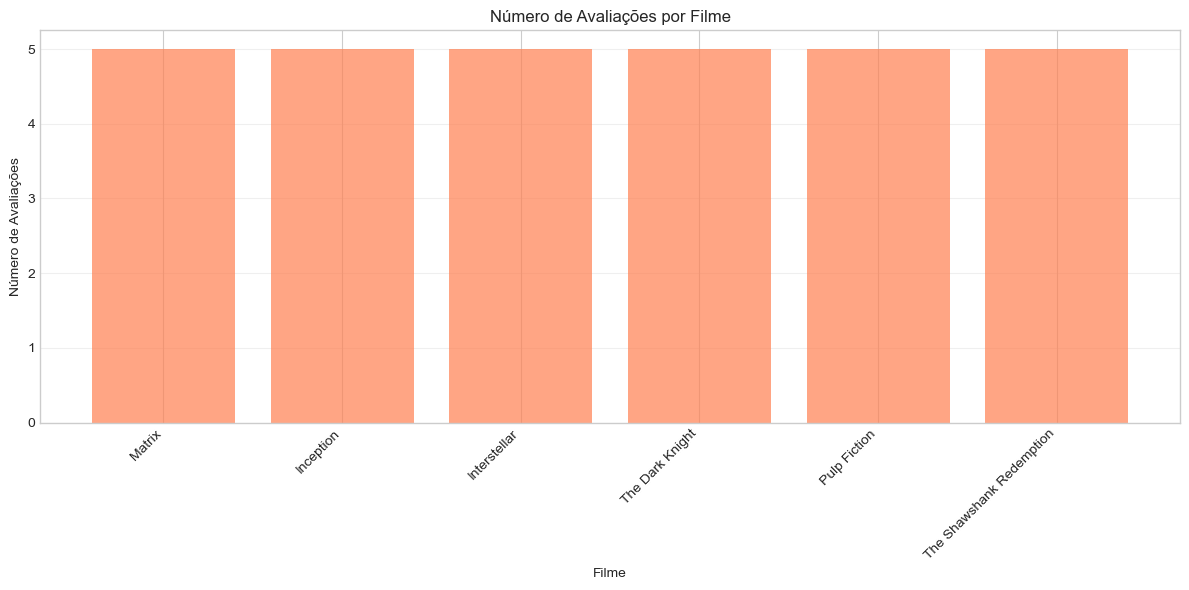

In [60]:
plt.figure(figsize=(12, 6))
plt.bar(avaliacoes_por_filme['title'], avaliacoes_por_filme['num_ratings'], 
        color='coral', alpha=0.7)
plt.xlabel('Filme')
plt.ylabel('Número de Avaliações')
plt.title('Número de Avaliações por Filme')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Criação da Matriz Usuário-Item

---

- Criar uma matriz de utilidade (utility matrix) pivotando os dados onde:
    
    - Linhas = usuários
    - Colunas = filmes
    - Valores = avaliações (ratings) _Dica: Use pivot_table() com index='user_id', columns='movie_id', values='rating'._
- Exibir a matriz de utilidade e observar os valores NaN (filmes não avaliados) _Dica: Valores NaN representam filmes que o usuário ainda não assistiu - isso é esperado!_
    
- Calcular a esparsidade da matriz (percentual de valores vazios) _Dica: Esparsidade = (número de NaN / total de células) × 100._
    
- Preencher valores NaN com 0 para cálculos de similaridade _Dica: Use fillna(0) - isso é necessário para os algoritmos de ML._
    
- **Visualização**: Criar um heatmap da matriz usuário-item _Dica: Use sns.heatmap() com annot=True para visualizar as avaliações._
    

In [6]:
# matriz de utilidade
matriz = notas_raw.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)
matriz

movie_id,101,102,103,104,105,106
user_id,,,,,,
1,5.00,4.00,3.50,4.50,3.00,2.50
2,4.50,5.00,4.00,3.00,2.50,3.00
3,5.00,5.00,4.50,4.00,2.00,3.50
4,4.50,4.00,3.50,3.50,2.50,4.00
5,4.00,3.50,3.00,3.00,2.00,4.50


In [9]:
# preencher filmes nao avaliados (nan) com 0
matriz.isna().sum()
# matriz = matriz.fillna(0) #se houvessem ausentes

movie_id
101    0
102    0
103    0
104    0
105    0
106    0
dtype: int64

In [19]:
# esparsidade
f'Esparsidade: {(matriz.isnull().sum().sum() / matriz.size) * 100:.2%}'

'Esparsidade: 0.00%'

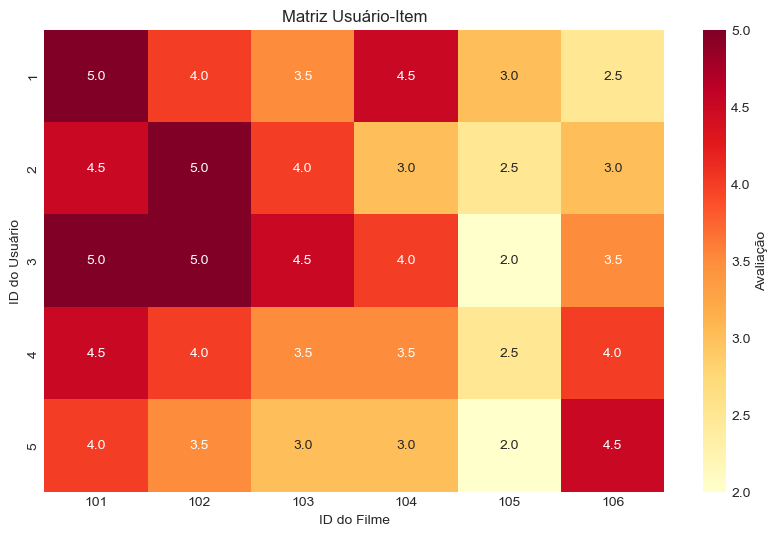

In [22]:
# heatmap
plt.figure(figsize=(10,6))
sns.heatmap(matriz, annot=True, fmt='.1f', cbar_kws={'label':'Avaliação'}, cmap='YlOrRd')
plt.title('Matriz Usuário-Item')
plt.xlabel('ID do Filme')
plt.ylabel('ID do Usuário')
plt.show()

### 3. Filtragem Colaborativa Baseada em Usuário (User-Based)

---

- Calcular a matriz de similaridade entre usuários usando cosine similarity _Dica: Use cosine_similarity() da sklearn com a matriz usuário-item._
    
- Criar um DataFrame com os scores de similaridade entre todos os pares de usuários _Dica: Transforme a matriz de similaridade em DataFrame com índices e colunas sendo os user_ids._
    
- Para um usuário específico (ex: usuário 1), identificar os 2 usuários mais similares _Dica: Ordene os scores de similaridade em ordem decrescente e pegue os top-K._
    
- Implementar uma função que recomende N filmes para um usuário baseado em usuários similares:
    
    1. Encontrar usuários similares
    2. Pegar filmes bem avaliados por usuários similares
    3. Filtrar filmes que o usuário alvo ainda não viu
    4. Retornar os top-N filmes _Dica: Combine as avaliações dos usuários similares, ponderando pela similaridade._
- **Visualização**: Criar um gráfico de barras mostrando os filmes recomendados com suas pontuações preditas
    

In [23]:
# matriz de similaridade
similaridade_usuarios = cosine_similarity(matriz)
similaridade_usuarios

array([[1.        , 0.97577949, 0.98031466, 0.97871458, 0.95132249],
       [0.97577949, 1.        , 0.99343157, 0.98527165, 0.96601451],
       [0.98031466, 0.99343157, 1.        , 0.98930885, 0.97344521],
       [0.97871458, 0.98527165, 0.98930885, 1.        , 0.99352772],
       [0.95132249, 0.96601451, 0.97344521, 0.99352772, 1.        ]])

In [24]:
# dataframe com pares
df_similaridade_usuarios = pd.DataFrame(similaridade_usuarios,
                                        index=matriz.index,
                                        columns=matriz.index
                                       )
df_similaridade_usuarios

user_id,1,2,3,4,5
user_id,,,,,
1,1.00,0.98,0.98,0.98,0.95
2,0.98,1.00,0.99,0.99,0.97
3,0.98,0.99,1.00,0.99,0.97
4,0.98,0.99,0.99,1.00,0.99
5,0.95,0.97,0.97,0.99,1.00


In [27]:
# similares ao usuario 1
similar1 = df_similaridade_usuarios[1].sort_values(ascending=False)
similar1 = similar1[similar1.index != 1] # remover o proprio
similar1 = similar1.head(2)
similar1

user_id
3   0.98
4   0.98
Name: 1, dtype: float64

In [33]:
# funcao baseada em usuarios
def recomendar_filmes_user_based(user_id, matriz, df_sim, df_filmes, top_n=3):
    """
    Recomenda filmes baseado em usuários similares
    
    Parâmetros:
    - user_id: ID do usuário para recomendar
    - matriz: DataFrame da matriz usuário-item (pode ter NaN ou 0 para não avaliados)
    - df_sim: DataFrame de similaridade entre usuários
    - df_filmes: DataFrame com informações dos filmes
    - top_n: Número de recomendações a retornar
    """
    # Obter usuários similares (top 3)
    usuarios_sim = df_sim[user_id].sort_values(ascending=False)
    usuarios_sim = usuarios_sim[usuarios_sim.index != user_id].head(3)
    
    print(f"   Usuários similares ao usuário {user_id}:")
    for uid, sim in usuarios_sim.items():
        print(f"      Usuário {uid}: similaridade = {sim:.3f}")
    print()
    
    # Identificar filmes já avaliados pelo usuário alvo
    # IMPORTANTE: Considerar tanto valores > 0 quanto valores não-NaN
    filmes_avaliados = matriz.loc[user_id]
    
    # Se a matriz tem NaN, considerar NaN como não avaliado
    if filmes_avaliados.isna().any():
        filmes_ja_vistos = filmes_avaliados[filmes_avaliados.notna()].index.tolist()
    else:
        # Se não tem NaN (preenchidos com 0), considerar > 0 como avaliado
        filmes_ja_vistos = filmes_avaliados[filmes_avaliados > 0].index.tolist()
    
    print(f"   Filmes já avaliados pelo usuário {user_id}: {len(filmes_ja_vistos)}")
    print(f"   Filmes disponíveis para recomendação: {len(matriz.columns) - len(filmes_ja_vistos)}")
    print()
    
    # Calcular pontuações ponderadas para filmes não vistos
    recomendacoes = {}
    for filme in matriz.columns:
        if filme not in filmes_ja_vistos:
            pontuacao_ponderada = 0
            soma_similaridades = 0
            
            # Ponderar pelas avaliações dos usuários similares
            for usuario_sim, sim_score in usuarios_sim.items():
                rating = matriz.loc[usuario_sim, filme]
                
                # Considerar apenas se o usuário similar avaliou este filme
                if pd.notna(rating) and rating > 0:
                    pontuacao_ponderada += rating * sim_score
                    soma_similaridades += sim_score
            
            # Só adicionar se pelo menos um usuário similar avaliou
            if soma_similaridades > 0:
                recomendacoes[filme] = pontuacao_ponderada / soma_similaridades
    
    print(f"   Filmes candidatos com pontuação: {len(recomendacoes)}")
    print()
    
    # Verificar se há recomendações
    if len(recomendacoes) == 0:
        print("   ⚠️ AVISO: Nenhum filme disponível para recomendar!")
        print("   Motivos possíveis:")
        print("   - Usuário já avaliou todos os filmes disponíveis")
        print("   - Usuários similares não avaliaram filmes novos")
        print()
        return pd.DataFrame(columns=['movie_id', 'title', 'score'])
    
    # Ordenar e pegar top-N
    recomendacoes_ordenadas = sorted(recomendacoes.items(), 
                                    key=lambda x: x[1], 
                                    reverse=True)[:top_n]
    
    # Adicionar títulos dos filmes
    resultado = []
    for filme_id, score in recomendacoes_ordenadas:
        titulo = df_filmes[df_filmes['movie_id'] == filme_id]['title'].values[0]
        resultado.append({
            'movie_id': filme_id, 
            'title': titulo, 
            'score': round(score, 3)
        })
    
    return pd.DataFrame(resultado)

In [37]:
# gerar recomendacoes
usuario_alvo = 3
recomendacoes_user = recomendar_filmes_user_based(usuario_alvo, matriz, 
                                                   df_similaridade_usuarios, filmes_raw)
print(f"Recomendações para Usuário {usuario_alvo} (User-Based):")
print(recomendacoes_user)
print()

   Usuários similares ao usuário 3:
      Usuário 2: similaridade = 0.993
      Usuário 4: similaridade = 0.989
      Usuário 1: similaridade = 0.980

   Filmes já avaliados pelo usuário 3: 6
   Filmes disponíveis para recomendação: 0

   Filmes candidatos com pontuação: 0

   ⚠️ AVISO: Nenhum filme disponível para recomendar!
   Motivos possíveis:
   - Usuário já avaliou todos os filmes disponíveis
   - Usuários similares não avaliaram filmes novos

Recomendações para Usuário 3 (User-Based):
Empty DataFrame
Columns: [movie_id, title, score]
Index: []



In [38]:
# plot com recomendacoes
if not recomendacoes_user.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(recomendacoes_user['title'], recomendacoes_user['score'], 
             color='steelblue', alpha=0.7)
    plt.xlabel('Pontuação Predita')
    plt.ylabel('Filme')
    plt.title(f'Filmes Recomendados para Usuário {usuario_alvo} (User-Based CF)')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4. Filtragem Colaborativa Baseada em Item (Item-Based)

---

- Transpor a matriz usuário-item para criar uma matriz item-usuário _Dica: Use .T para transpor a matriz._
    
- Calcular a matriz de similaridade entre filmes usando cosine similarity _Dica: Aplique cosine_similarity() na matriz transposta._
    
- Criar um DataFrame com os scores de similaridade entre todos os pares de filmes _Dica: Use os movie_ids como índices e colunas._
    
- Para um filme específico (ex: filme 101 - Matrix), identificar os 3 filmes mais similares _Dica: Ordene os scores e filtre os top-K, excluindo o próprio filme._
    
- **Visualização**: Criar um heatmap mostrando a similaridade entre todos os filmes _Dica: Use sns.heatmap() e faça merge com movies_info para mostrar os títulos dos filmes._
    

In [41]:
# transpor matriz
matriz_item_usuario = matriz.T
matriz_item_usuario

user_id,1,2,3,4,5
movie_id,,,,,
101,5.00,4.50,5.00,4.50,4.00
102,4.00,5.00,5.00,4.00,3.50
103,3.50,4.00,4.50,3.50,3.00
104,4.50,3.00,4.00,3.50,3.00
105,3.00,2.50,2.00,2.50,2.00
106,2.50,3.00,3.50,4.00,4.50


### 5. Implementação com Surprise Library (SVD)
---

- Preparar os dados no formato da biblioteca Surprise _Dica: Use Reader(rating_scale=(0.5, 5.0)) e Dataset.load_from_df()._
    
- Dividir os dados em conjunto de treino (80%) e teste (20%) _Dica: Use train_test_split() da Surprise._
    
- Treinar um modelo SVD (Singular Value Decomposition) _Dica: Instancie SVD() e use o método fit() com os dados de treino._
    
- Fazer predições no conjunto de teste e calcular RMSE e MAE _Dica: Use test() para predições e accuracy.rmse() e accuracy.mae() para métricas._
    
- Implementar validação cruzada com 5 folds _Dica: Use cross_validate() com cv=5._
    
- Para um usuário específico, gerar recomendações dos top-5 filmes não avaliados _Dica: Prediga avaliações para todos os filmes não vistos e ordene por predição._
    
- **Visualização**: Comparar avaliações reais vs predições em um gráfico de dispersão _Dica: Plot das avaliações reais (eixo x) vs predições (eixo y)._
    

### 6. Avaliação e Comparação de Modelos (Desafio Avançado)
---

- Implementar também o modelo KNN (K-Nearest Neighbors) da Surprise _Dica: Use KNNBasic() ou KNNWithMeans() e treine com os mesmos dados._
    
- Comparar as métricas (RMSE, MAE) entre SVD e KNN _Dica: Crie uma tabela comparativa com as métricas de cada modelo._
    
- Calcular Precision@K e Recall@K para avaliar a qualidade das recomendações _Dica: Para cada usuário, considere "relevante" filmes com rating >= 4.0._
    
- Analisar o problema de cold start:
    
    - Simular um novo usuário sem histórico de avaliações
    - Tentar gerar recomendações e documentar as limitações _Dica: Discuta estratégias como popular items ou hybrid approach._
- **Visualização**: Criar um gráfico comparativo das métricas dos diferentes modelos _Dica: Gráfico de barras agrupadas comparando RMSE e MAE de SVD vs KNN._
    
- **Análise Final**:
    
    - Identificar qual modelo teve melhor performance
    - Discutir vantagens e desvantagens de cada abordagem
    - Sugerir melhorias para o sistema de recomendação

### 7. Análise de Negócio e Insights (Extra)
---

- Identificar os filmes mais populares (mais avaliados) _Dica: Conte o número de avaliações por filme._
    
- Calcular a média de avaliação por filme e identificar os mais bem avaliados _Dica: Agrupe por movie_id e calcule mean(rating)._
    
- Analisar o viés de popularidade (popularity bias):
    
    - Verificar se o sistema recomenda principalmente filmes populares
    - Calcular a diversidade das recomendações _Dica: Compare a distribuição de popularidade entre itens recomendados vs todos os itens._
- Criar uma análise temporal:
    
    - Agrupar avaliações por período (mês/semana)
    - Verificar se há padrões de consumo ao longo do tempo _Dica: Converta timestamp para datetime e use groupby com Grouper._
- **Visualização**: Dashboard com múltiplos gráficos mostrando:
    
    - Top 5 filmes mais populares
    - Top 5 filmes mais bem avaliados
    - Evolução do número de avaliações ao longo do tempo
    - Distribuição de gêneros nas recomendações

## Reflexão e Perguntas Adicionais

---

Após concluir as tarefas, reflita sobre os seguintes pontos:

1. **Qualidade das Recomendações**: As recomendações geradas fazem sentido considerando o perfil dos usuários? Consegue identificar padrões nas preferências?
    
2. **Comparação de Abordagens**: Qual abordagem (user-based, item-based, SVD, KNN) gerou melhores resultados? Por quê? Quais são os trade-offs de cada método?
    
3. **Desafios Identificados**:
    
    - Como lidar com o problema de cold start (novos usuários/filmes)?
    - Como endereçar a esparsidade dos dados?
    - Como mitigar o popularity bias que faz filmes populares serem recomendados excessivamente?
4. **Escalabilidade**: Sistemas de recomendação em larga escala processam milhões de usuários e itens. Como os métodos implementados se comportariam com datasets maiores? Quais otimizações seriam necessárias?
    
5. **Métricas de Negócio**: Além de RMSE e MAE, quais outras métricas seriam importantes para o negócio? Pense em: taxa de cliques, tempo de engajamento, diversidade, novidade, serendipity.
    
6. **Sistemas Híbridos**: Como você combinaria filtragem colaborativa com filtragem baseada em conteúdo (usando gêneros, ano, etc.) para melhorar as recomendações?
    
7. **Aspectos Éticos**: Como garantir que o sistema de recomendação não crie "bolhas de filtro" que limitam a exposição dos usuários a conteúdo diverso?
    
8. **Tendências Atuais**: Plataformas como Facebook Reels estão explorando técnicas avançadas de modelagem, incluindo large language models e representações de usuário mais granulares. Como essas tendências poderiam ser aplicadas ao seu sistema?
    

## Recursos Adicionais

---

Para aprofundar seus conhecimentos em sistemas de recomendação:

- **Documentação do Scikit-Surprise**: https://surprise.readthedocs.io/
- **Documentação do Scikit-Learn**: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics.pairwise
- **Dataset MovieLens**: https://grouplens.org/datasets/movielens/ - Dataset de referência para sistemas de recomendação
- **Artigo: Collaborative Filtering**: https://towardsdatascience.com/
- **Netflix Prize**: https://www.netflixprize.com/ - Competição histórica de recomendação
- **Book: "Recommender Systems Handbook"** - Ricci, Rokach, Shapira
- **Papers**:
    - "Improve the Personalization of Large-Scale Ranking Systems by Integrating User Survey Feedback" (Meta, 2026)
    - Matrix Factorization Techniques for Recommender Systems (Koren et al.)

---

## Conceitos-Chave

---

**Filtragem Colaborativa**: Técnica que faz recomendações baseadas em padrões de comportamento de múltiplos usuários. Assume que usuários que concordaram no passado concordarão no futuro.

**User-Based CF**: Encontra usuários similares e recomenda itens que esses usuários similares gostaram.

**Item-Based CF**: Encontra itens similares baseado em padrões de avaliação e recomenda itens similares aos que o usuário já gostou.

**Cosine Similarity**: Métrica que mede a similaridade entre vetores baseada no ângulo entre eles, preferida sobre distância euclidiana em dados de alta dimensionalidade.

**SVD (Singular Value Decomposition)**: Técnica de fatoração matricial que decompõe a matriz em produtos de matrizes de menor dimensionalidade, extraindo features latentes por ordem de importância.

**Cold Start Problem**: Dificuldade em gerar recomendações para novos usuários ou novos itens devido à falta de dados históricos.

**Data Sparsity**: Problema causado por muitos valores zero na matriz usuário-item, onde poucos usuários avaliam poucos itens.

**RMSE (Root Mean Squared Error)**: Métrica que penaliza mais fortemente erros grandes nas predições.

**Precision@K**: Proporção de itens relevantes entre os K itens recomendados.

**Hybrid Systems**: Sistemas que combinam filtragem colaborativa e baseada em conteúdo para superar limitações de cada abordagem.